# WW2 weather conditions

#### Life cycle of Project

- Understanding the Problem Statement
- Data Collection
- Data Checks
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1 Objective
Is there a relationship between the daily minimum and maximum temperature? Can you predict the maximum temperature given the minimum temperature?

### 2 Data Collection
- Data Source : "https://www.kaggle.com/datasets/smid80/weatherww2/data"
- Data consist of 119040 rows and 31 columns

### 2.1 Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Summary of Weather.csv')

In [4]:
df.shape

(119040, 31)

In [5]:
df.head()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.head()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.columns

Index(['STA', 'Date', 'Precip', 'WindGustSpd', 'MaxTemp', 'MinTemp',
       'MeanTemp', 'Snowfall', 'PoorWeather', 'YR', 'MO', 'DA', 'PRCP', 'DR',
       'SPD', 'MAX', 'MIN', 'MEA', 'SNF', 'SND', 'FT', 'FB', 'FTI', 'ITH',
       'PGT', 'TSHDSBRSGF', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE'],
      dtype='object')

In [9]:
df.drop(columns=['PRCP', 'MAX', 'MIN', 'MEA', 'SNF'],inplace=True)

### 3 Data Checks
- Missing Values
- Duplicates
- Data Types
- Statistics of Dataset

### 3.1 Checking Missing Values
- Better to drop those columns whose having nulls >= 70%

In [10]:
ls = (df.isnull().sum()/df.shape[0]).sort_values(ascending=False)

In [11]:
cols_to_remove = ls[ls>=0.7]

In [12]:
df.drop(columns=cols_to_remove.index,inplace=True)

### 3.2 Checking Duplicates

In [13]:
print('Duplicate rows :',df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows : 10


### 3.3 Checking Data Types and modifying datatypes if required

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119030 entries, 0 to 119039
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   STA       119030 non-null  int64         
 1   Date      119030 non-null  datetime64[ns]
 2   Precip    119030 non-null  object        
 3   MaxTemp   119030 non-null  float64       
 4   MinTemp   119030 non-null  float64       
 5   MeanTemp  119030 non-null  float64       
 6   Snowfall  117867 non-null  object        
 7   YR        119030 non-null  int64         
 8   MO        119030 non-null  int64         
 9   DA        119030 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 10.0+ MB


In [15]:
df['Precip'] = pd.to_numeric(df['Precip'], errors='coerce')
df['Snowfall'] = pd.to_numeric(df['Snowfall'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119030 entries, 0 to 119039
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   STA       119030 non-null  int64         
 1   Date      119030 non-null  datetime64[ns]
 2   Precip    102278 non-null  float64       
 3   MaxTemp   119030 non-null  float64       
 4   MinTemp   119030 non-null  float64       
 5   MeanTemp  119030 non-null  float64       
 6   Snowfall  117823 non-null  float64       
 7   YR        119030 non-null  int64         
 8   MO        119030 non-null  int64         
 9   DA        119030 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(4)
memory usage: 10.0 MB


### 3.4 Statistics of the Data

In [16]:
df.drop(['Date','YR','MO','DA'],axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
STA,119030.0,29659.059456,20954.049325,10001.000000,11801.000000,22508.000000,33501.000000,82506.000000
Precip,102278.0,3.754205,11.567099,0.000000,0.000000,0.000000,1.524000,307.340000
MaxTemp,119030.0,27.044545,8.717924,-33.333333,25.555556,29.444444,31.666667,50.000000
MinTemp,119030.0,17.789446,8.334910,-38.333333,15.000000,21.111111,23.333333,34.444444
MeanTemp,119030.0,22.411320,8.298256,-35.555556,20.555556,25.555556,27.222222,40.000000
Snowfall,117823.0,0.245564,2.626711,0.000000,0.000000,0.000000,0.000000,86.360000


### 4 Exploratory Data Analysis

### 4.1 Univariate Analysis

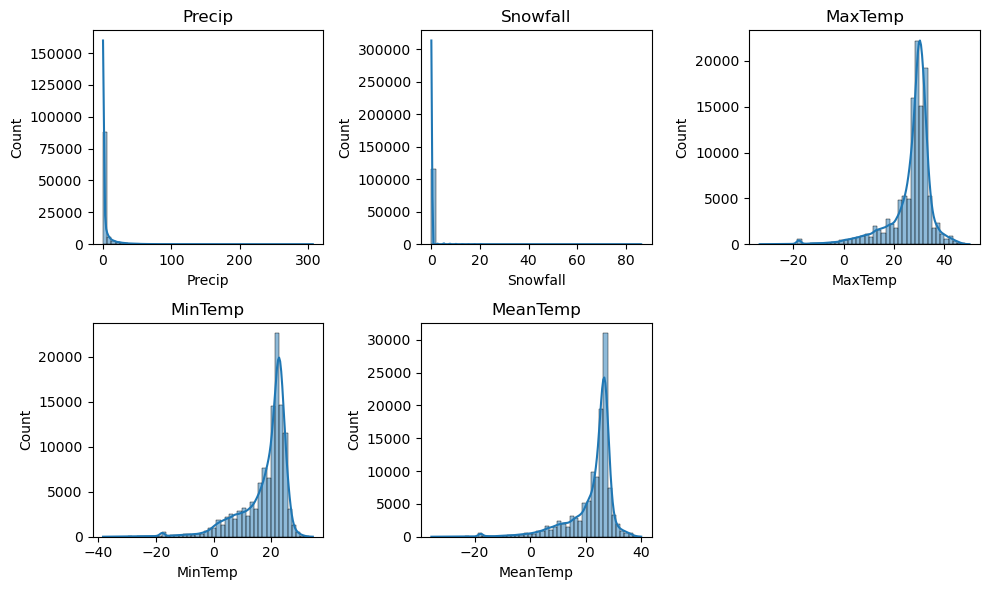

In [17]:
plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
sns.histplot(df['Precip'], kde=True, bins=50)
plt.title('Precip')

plt.subplot(2,3,2)
sns.histplot(df['Snowfall'], kde=True, bins=50)
plt.title('Snowfall')

plt.subplot(2,3,3)
sns.histplot(df['MaxTemp'], kde=True, bins=50)
plt.title('MaxTemp')

plt.subplot(2,3,4)
sns.histplot(df['MinTemp'], kde=True, bins=50)
plt.title('MinTemp')

plt.subplot(2,3,5)
sns.histplot(df['MeanTemp'], kde=True, bins=50)
plt.title('MeanTemp')

plt.tight_layout()
plt.show()


<Axes: >

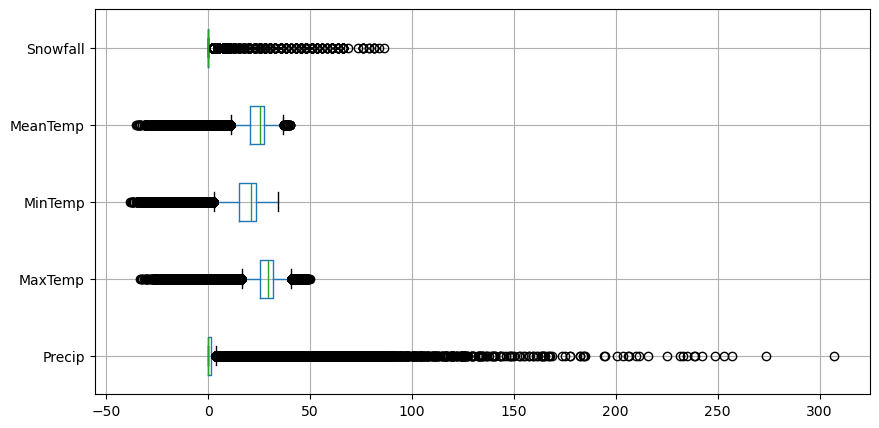

In [18]:
num_cols = ['Precip','MaxTemp','MinTemp','MeanTemp','Snowfall']

plt.figure(figsize=(10,5))
df[num_cols].boxplot(vert=False)

### Insights
- Observed significant skewness in Snowfall and Precip, applied logarithmic transformation to reduce skewness.

### Converting Columns

In [19]:
df['log_Precip']=np.log1p(df['Precip'])
df['log_Snowfall']=np.log1p(df['Snowfall'])

<Axes: >

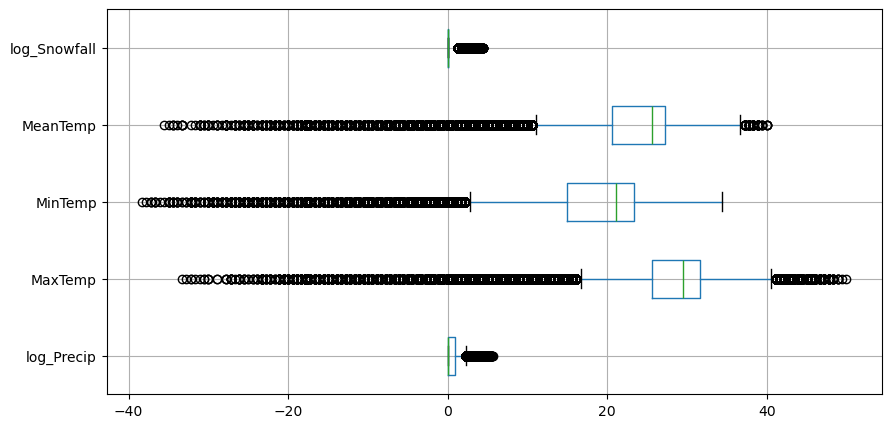

In [20]:
log_num_cols = ['log_Precip','MaxTemp','MinTemp','MeanTemp','log_Snowfall']

plt.figure(figsize=(10,5))
df[log_num_cols].boxplot(vert=False)

### Insights
- There is no need to remove outliers as we see from graph that outliers fall within a normal ranges of features

<Axes: >

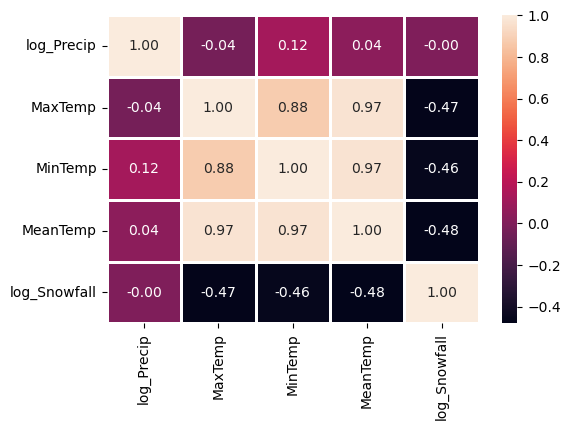

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df[log_num_cols].corr(),annot=True,fmt='.2f',linewidth=1,linecolor='white')

### Insights
- MeanTemp and MinTemp show strong correlation with MaxTemp. Additionally, MeanTemp and MinTemp are highly correlated with each other, indicating multicollinearity. Therefore, PCA was applied to reduce redundancy among features.

### 5 Data Pre-Processing

In [22]:
df_log = df.copy()

In [23]:
df_log.drop(columns=['Precip','Snowfall'],inplace=True)

### 5.1 Imputing Null

In [24]:
df_log.isnull().sum()

STA                 0
Date                0
MaxTemp             0
MinTemp             0
MeanTemp            0
YR                  0
MO                  0
DA                  0
log_Precip      16752
log_Snowfall     1207
dtype: int64

In [25]:
null_cols = ['log_Precip','log_Snowfall']

In [26]:
df_mean = df_log.copy()
df_median = df_log.copy()
df_knn = df_log.copy()

In [27]:
for col in null_cols:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())
for col in null_cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

In [28]:
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=5)
df_knn[null_cols]=imputer.fit_transform(df_knn[null_cols])

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### 6 Model Training 

In [30]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV

In [32]:
dataframes = {
    'df_mean': df_mean,
    'df_median': df_median,
    'df_knn': df_knn
}

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

param_grids = {
    "Ridge": {
        'regressor__alpha': [0.1, 1.0, 10.0]          
    },
    "Lasso": {
        'regressor__alpha': [0.01, 0.1, 1.0]          
    },
    "DecisionTree": {
        'regressor__max_depth': [5, 10, None],          
        'regressor__min_samples_split': [2, 10],     
        'regressor__min_samples_leaf': [1, 4],          
        'regressor__max_features': ['sqrt', None]       
    },
    "RandomForest": {
        'regressor__n_estimators': [100],              
        'regressor__max_depth': [5, None],             
        'regressor__min_samples_split': [2, 10],        
        'regressor__min_samples_leaf': [1, 2],          
        'regressor__max_features': ['sqrt']            
    },
    "AdaBoost": {
        'regressor__n_estimators': [50, 100],          
        'regressor__learning_rate': [0.1, 1.0],        
    },
    "GradientBoosting": {
        'regressor__n_estimators': [100],              
        'regressor__learning_rate': [0.05, 0.1],        
        'regressor__max_depth': [3, 5],                 
        'regressor__min_samples_split': [2],           
        'regressor__min_samples_leaf': [1, 4],         
        'regressor__subsample': [0.8]                  
    },
    "KNN": {
        'regressor__n_neighbors': [5, 7, 11],          
        'regressor__weights': ['uniform', 'distance'],  
        'regressor__metric': ['euclidean', 'manhattan'] 
    }
}

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [34]:
df_mean.columns

Index(['STA', 'Date', 'MaxTemp', 'MinTemp', 'MeanTemp', 'YR', 'MO', 'DA',
       'log_Precip', 'log_Snowfall'],
      dtype='object')

In [35]:
results = []

for df_name, df_ in dataframes.items():
    
    X = df_.drop(columns=['MaxTemp', 'STA', 'Date'])
    y = df_['MaxTemp']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    for model_name, model in models.items():
        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('pca', PCA()),              
            ('regressor', model)
        ])
        
    
        param_grid = param_grids.get(model_name, {}).copy()
        param_grid.update({
            'pca__n_components': [2,3,4,5,6,7]   #Choosing Best features to reduce multicollinearity
        })
        
        gs = GridSearchCV(
            pipe,
            param_grid,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        gs.fit(X_train, y_train)
        y_pred_t = gs.best_estimator_.predict(X_train)
        y_pred = gs.best_estimator_.predict(X_test)
        
        results.append({
            'Dataframe': df_name,
            'Model': model_name,
            'Best Params': gs.best_params_,
            'Best PCA Components': gs.best_params_.get('pca__n_components'), 
            'R2_train': r2_score(y_train, y_pred_t),
            'R2_test': r2_score(y_test, y_pred),
            'RMSE_train': mean_squared_error(y_train, y_pred_t),
            'RMSE_test': mean_squared_error(y_test, y_pred),
            'MAE_train': mean_absolute_error(y_train, y_pred_t),
            'MAE_test': mean_absolute_error(y_test, y_pred)
        })

### 7 Choosing Best Model

In [48]:
results_df=pd.DataFrame(results)

In [41]:
results_df.to_excel('results_df.xlsx')

In [50]:
results_df.sort_values('RMSE_test').head(5)

,Dataframe,Model,Best Params,Best PCA Components,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test
14,df_median,GradientBoosting,"{'pca__n_components': 7, 'regressor__learning_...",7,0.994932,0.993002,0.388077,0.522398,0.406664,0.426975
22,df_knn,GradientBoosting,"{'pca__n_components': 7, 'regressor__learning_...",7,0.995767,0.992625,0.324153,0.550546,0.398320,0.423616
6,df_mean,GradientBoosting,"{'pca__n_components': 7, 'regressor__learning_...",7,0.995492,0.992453,0.345199,0.563382,0.405685,0.432295
12,df_median,RandomForest,"{'pca__n_components': 7, 'regressor__max_depth...",7,0.998660,0.991783,0.102579,0.613415,0.175082,0.437255
20,df_knn,RandomForest,"{'pca__n_components': 7, 'regressor__max_depth...",7,0.998647,0.991638,0.103589,0.624219,0.172107,0.438159


In [46]:
results_df.loc[14]['Best Params']

{'pca__n_components': 7,
 'regressor__learning_rate': 0.1,
 'regressor__max_depth': 5,
 'regressor__min_samples_leaf': 4,
 'regressor__min_samples_split': 2,
 'regressor__n_estimators': 100,
 'regressor__subsample': 0.8}

Best model retrained successfully!

Train Performance:
   R²   : 0.994932
   RMSE : 0.622958
   MAE  : 0.406664

Test Performance:
   R²   : 0.993002
   RMSE : 0.722771
   MAE  : 0.426975

 Overfitting Check:
   R² Gap  : 0.0019 
   RMSE Gap: 0.0998


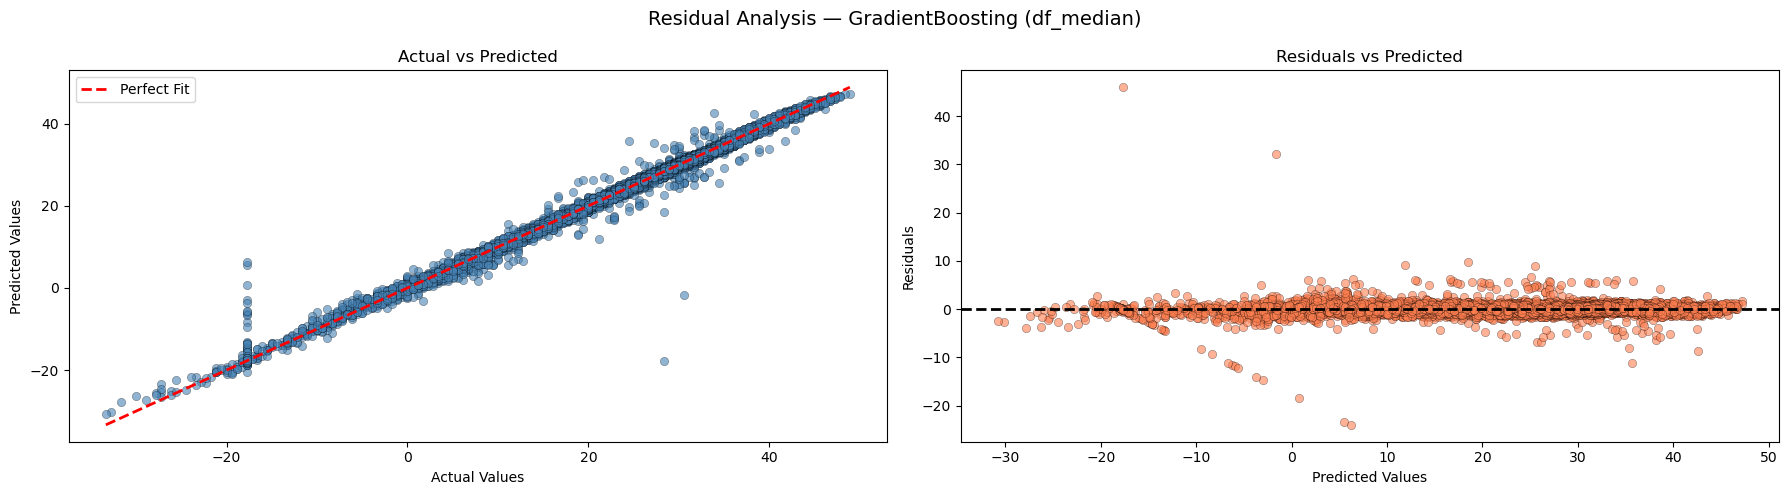

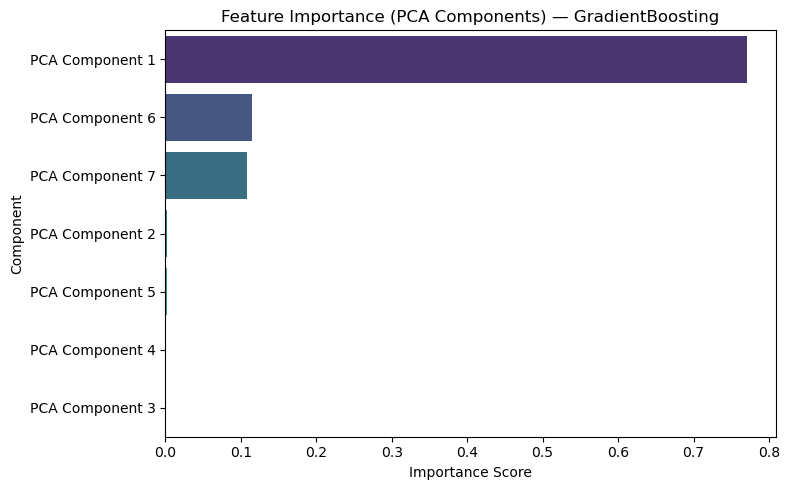

      Component  Importance
PCA Component 1    0.770423
PCA Component 6    0.115200
PCA Component 7    0.108066
PCA Component 2    0.002834
PCA Component 5    0.002789
PCA Component 4    0.000516
PCA Component 3    0.000172

 Final Model Summary:
             R2      RMSE       MAE
Train  0.994932  0.622958  0.406664
Test   0.993002  0.722771  0.426975


In [58]:
best_model_name = 'GradientBoosting'
best_dataframe  = df_median         

best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=7)),
    ('regressor', GradientBoostingRegressor(
        learning_rate=0.1,               
        max_depth=5,               
        min_samples_leaf=4,               
        min_samples_split=2,                       
        n_estimators=100,               
        subsample=0.8,               
        random_state=42
    ))
])

X_best = df_median.drop(columns=['MaxTemp', 'STA', 'Date'])
y_best = df_median['MaxTemp']
    
X_train, X_test, y_train, y_test = train_test_split(X_best, y_best, test_size=0.3, random_state=42)

best_pipeline.fit(X_train, y_train)

print("Best model retrained successfully!")


y_pred_train = best_pipeline.predict(X_train)
y_pred_test  = best_pipeline.predict(X_test)

def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{label} Performance:")
    print(f"   R²   : {r2:.6f}")
    print(f"   RMSE : {rmse:.6f}")
    print(f"   MAE  : {mae:.6f}")
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

train_metrics = evaluate(y_train, y_pred_train, "Train")
test_metrics  = evaluate(y_test,  y_pred_test,  "Test")

# Overfitting check
print(f"\n Overfitting Check:")
print(f"   R² Gap  : {train_metrics['R2']  - test_metrics['R2']:.4f} ")
print(f"   RMSE Gap: {test_metrics['RMSE'] - train_metrics['RMSE']:.4f}")



residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Residual Analysis — GradientBoosting (df_median)', fontsize=14)

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolors='k', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()


axes[1].scatter(y_pred_test, residuals, alpha=0.6, color='coral', edgecolors='k', linewidth=0.3)
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')


plt.tight_layout()
plt.show()



importances = best_pipeline.named_steps['regressor'].feature_importances_
pca_labels  = [f'PCA Component {i+1}' for i in range(len(importances))]

feat_imp_df = pd.DataFrame({
    'Component': pca_labels,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Component', palette='viridis')
plt.title('Feature Importance (PCA Components) — GradientBoosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(feat_imp_df.to_string(index=False))


summary = pd.DataFrame([train_metrics, test_metrics], index=['Train', 'Test'])
print("\n Final Model Summary:")
print(summary.round(6))